<a id="top"></a>
# Chapter 5 — Higher-order topology and the Kitaev chain

**PythTB — Tight-Binding Physics from Theory to Code** · Part II — Topological matter · chapter 5 of 8

[◀ 4 Chern and Z₂ insulators: Haldane, Kane–Mele, BHZ](PythTB_04_Chern_and_Z2.ipynb) · [Contents of the book](README.md) · [6 Weyl semimetals and the axion angle ▶](PythTB_06_Weyl_and_Axion.ipynb)

**In this chapter**

- [§17 The BBH quadrupole insulator — higher-order topology and nested Wilson loops](#sec-17)
- [§18 The Kitaev chain — superconductivity smuggled in as extra orbitals](#sec-18)

All chapters: [0](PythTB_00_Introduction.ipynb) · [1](PythTB_01_Foundations.ipynb) · [2](PythTB_02_Finite_Systems_and_Berry_Phases.ipynb) · [3](PythTB_03_Three_Dimensions_and_Wannier.ipynb) · [4](PythTB_04_Chern_and_Z2.ipynb) · [5](PythTB_05_Higher_Order_and_Kitaev.ipynb) · [6](PythTB_06_Weyl_and_Axion.ipynb) · [7](PythTB_07_Stretching_PythTB.ipynb) · [8](PythTB_08_What_PythTB_Cannot_Do.ipynb) · exercises: [Parts I–II](PythTB_Exercises_I-II.ipynb) · [Parts III–IV](PythTB_Exercises_III-IV.ipynb)

*Every notebook runs on its own: the setup cell below is identical in all of them, and a chapter that reuses a model from an earlier one rebuilds it in a short recap cell. Section numbers (§1–31), figure numbers and cross-references are global to the book.*

In [1]:
# ---- shared setup: this cell is identical in every chapter of the book ----------
import os
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

import pythtb
from pythtb import Lattice, TBModel, Mesh, WFArray, Wannier, W90

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.figsize": (7.0, 4.2),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

# the Wannier90 silicon data (§12) lives in data/ at the repository root
DATA_DIR = next((d for d in ("data", os.path.join("..", "data")) if os.path.isdir(d)), "data")

rng = np.random.default_rng(2026)          # single seed for every stochastic cell

_CHECKS = {"pass": 0, "fail": 0}
_FIG = {"n": 44}               # figure numbers run through the whole book

def check(label, ok, detail=""):
    '''Inline physics check; prints PASS/FAIL and tallies for the final summary.'''
    ok = bool(ok)
    _CHECKS["pass" if ok else "fail"] += 1
    print(f"[{'PASS' if ok else 'FAIL'}] {label}" + (f" — {detail}" if detail else ""))
    return ok

def caption(text):
    '''Numbered caption rendered directly below the figure it describes.'''
    _FIG["n"] += 1
    display(HTML(
        f"<div style='max-width:780px;margin:2px 0 14px 12px;font-size:0.92em;"
        f"color:#444;border-left:3px solid #bbb;padding-left:10px'>"
        f"<b>Figure {_FIG['n']}.</b> {text}</div>"))

def draw_bonds(ax, xy, pairs, color="0.55", lw=1.0, ls="-", zorder=1):
    '''Draw a set of bonds (index pairs) between the 2D points xy on axis ax —
    used throughout to depict the actual system before computing on it.'''
    for i, j in pairs:
        ax.plot(xy[[i, j], 0], xy[[i, j], 1], ls, color=color, lw=lw, zorder=zorder)

print("pythtb", pythtb.__version__, "| numpy", np.__version__, "| chapter 5")
t_chapter_start = time.time()

pythtb 2.0.0 | numpy 2.5.2 | chapter 5


<a id="sec-17"></a>

## 17. The BBH quadrupole insulator — higher-order topology and nested Wilson loops

Benalcazar–Bernevig–Hughes (2017): a 2D insulator whose bulk dipole (polarization) vanishes but
whose bulk **quadrupole moment** $q_{xy} = e/2$ is quantized — producing gapless states not on
edges (the edges are gapped) but on **corners**: half-charges at $E=0$. The model: a square lattice
with four orbitals, intracell hoppings $\gamma$, intercell hoppings $\lambda$, and one negative
bond per plaquette so every square encloses $\pi$ flux. Topological when $|\gamma| < |\lambda|$.

The invariant needs a construction beyond a plain Wilson loop: the **nested Wilson loop**. First
Wilson loop along $k_x$ → the two *Wannier bands* $\nu^\pm_x(k_y)$ are gapped; then the Berry phase
*of a Wannier band* along $k_y$ → the Wannier-sector polarization $p_y^{\nu}$, quantized to jump by
$1/2$ between the trivial and quadrupole phases. PythTB has no
one-call nested Wilson, but it hands us everything needed — eigenvectors from `solve_ham`, or the
Wilson unitaries from `WFArray.wilson_loop` — so we build it by hand. This is the notebook's first
real *stretch*: the package as a linear-algebra toolkit rather than a menu.

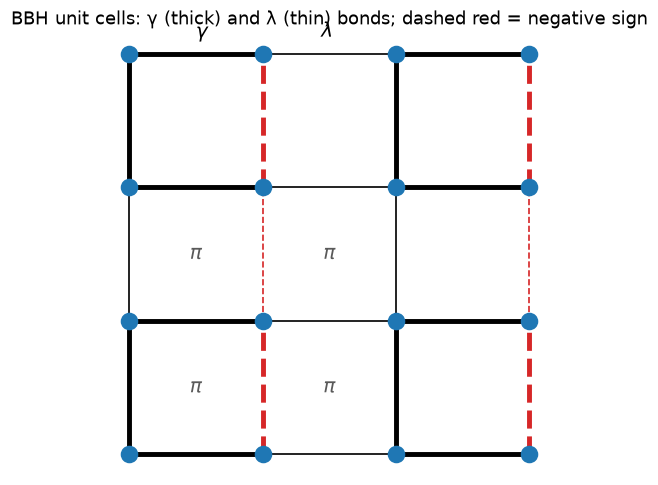

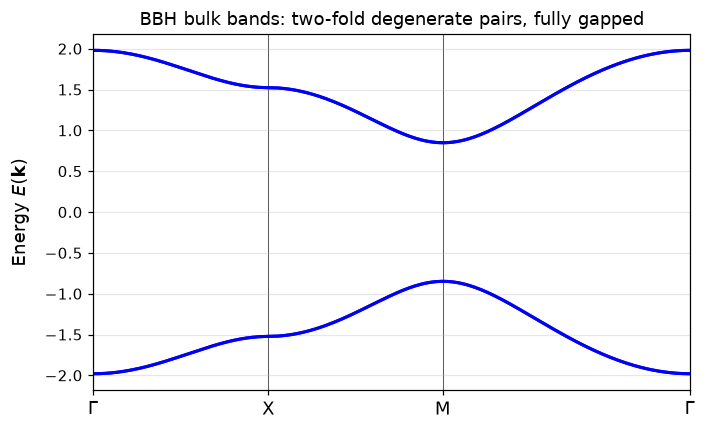

[PASS] BBH spectrum is chiral-symmetric (E and -E in pairs)


True

In [2]:
def bbh(gamma, lam):
    '''BBH quadrupole model: 4 orbitals on the square lattice, pi flux per plaquette.
    Vertical bonds in the x=1/2 column carry the minus sign.'''
    lat = Lattice(lat_vecs=[[1, 0], [0, 1]],
                  orb_vecs=[[0, 0], [0.5, 0], [0, 0.5], [0.5, 0.5]],
                  periodic_dirs=[0, 1])
    m = TBModel(lat)
    # intracell
    m.set_hop(gamma, 0, 1, [0, 0])          # x bond, row y=0
    m.set_hop(gamma, 2, 3, [0, 0])          # x bond, row y=1/2
    m.set_hop(gamma, 0, 2, [0, 0])          # y bond, column x=0
    m.set_hop(-gamma, 1, 3, [0, 0])         # y bond, column x=1/2  (negative)
    # intercell
    m.set_hop(lam, 1, 0, [1, 0])
    m.set_hop(lam, 3, 2, [1, 0])
    m.set_hop(lam, 2, 0, [0, 1])
    m.set_hop(-lam, 3, 1, [0, 1])           # negative column continues across cells
    return m

gamma, lam = 0.4, 1.0                        # |gamma| < |lambda|: quadrupole phase
qm = bbh(gamma, lam)

# the model drawn: 2x2 cells, intracell gamma (thick) vs intercell lambda (thin),
# negative bonds dashed red — check that EVERY square plaquette has exactly one
orbs = np.array([[0, 0], [0.5, 0], [0, 0.5], [0.5, 0.5]])
fig, ax = plt.subplots(figsize=(5.6, 5.2))
for cx in range(2):
    for cy in range(2):
        o = orbs + [cx, cy]
        bonds = [(0, 1, gamma, +1), (2, 3, gamma, +1), (0, 2, gamma, +1), (1, 3, gamma, -1)]
        for i, j, amp, sgn in bonds:
            ax.plot(o[[i, j], 0], o[[i, j], 1],
                    "--" if sgn < 0 else "-", color="C3" if sgn < 0 else "k",
                    lw=3.2, zorder=2)
        # intercell bonds to the right / top
        for (i, j, dx, dy, sgn) in [(1, 0, 1, 0, +1), (3, 2, 1, 0, +1),
                                    (2, 0, 0, 1, +1), (3, 1, 0, 1, -1)]:
            p1, p2 = o[i], orbs[j] + [cx + dx, cy + dy]
            if p2[0] < 1.8 and p2[1] < 1.8:
                ax.plot([p1[0], p2[0]], [p1[1], p2[1]],
                        "--" if sgn < 0 else "-", color="C3" if sgn < 0 else "k",
                        lw=1.1, zorder=2)
        ax.scatter(o[:, 0], o[:, 1], s=110, c="C0", zorder=3)
for (x, y) in [(0.25, 0.25), (0.75, 0.25), (0.25, 0.75), (0.75, 0.75)]:
    ax.annotate(r"$\pi$", (x, y), ha="center", va="center", fontsize=13, color="0.35")
ax.annotate(r"$\gamma$", (0.25, 1.56), fontsize=13)
ax.annotate(r"$\lambda$", (0.72, 1.56), fontsize=13)
ax.set_aspect("equal"); ax.axis("off")
ax.set_title("BBH unit cells: γ (thick) and λ (thin) bonds; dashed red = negative sign")
plt.show()
caption("The BBH quadrupole model: four orbitals per cell coupled by intracell γ "
        "(thick) and intercell λ (thin) bonds, with the vertical bonds of one "
        "column negated (dashed red). Multiply the bond signs around any elementary "
        "square: always −1, i.e. π flux per plaquette. The flux gaps the edge "
        "spectrum too — that is what demotes the topological states from edges to "
        "corners, one dimension down.")

fig, ax = qm.plot_bands([[0, 0], [0.5, 0], [0.5, 0.5], [0, 0]],
                        k_node_labels=[r"$\Gamma$", "X", "M", r"$\Gamma$"], nk=301)
ax.set_title("BBH bulk bands: two-fold degenerate pairs, fully gapped")
plt.show()
caption("BBH bulk bands: two doubly-degenerate pairs separated by a full gap. "
        "Nothing here betrays the topology — bulk dipole moments vanish by "
        "symmetry, and only the quadrupole moment, extracted by the nested Wilson "
        "loop below, distinguishes this insulator from a trivial one.")

ev = np.sort(qm.solve_ham(rng.random((50, 2))), axis=1)
check("BBH spectrum is chiral-symmetric (E and -E in pairs)",
      np.allclose(ev, -ev[:, ::-1], atol=1e-10))

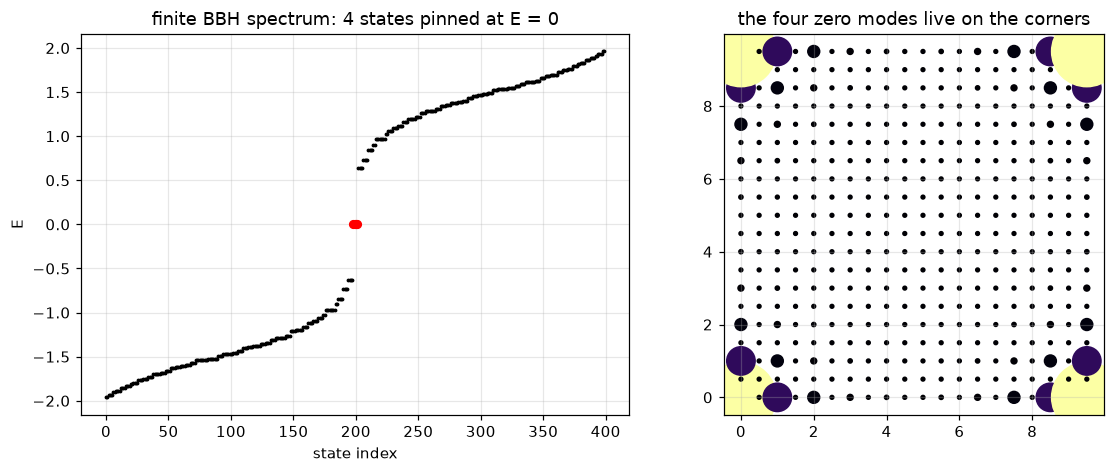

[PASS] four corner-pinned zero modes — found 4
[PASS] corner charge is quantized to e/2 — |Q_corner| = 0.5000


True

In [3]:
# corner states: finite sample in the topological phase
fin = bbh(gamma, lam).make_finite(periodic_dirs=[0, 1], num_cells=[10, 10])
evals, evecs = fin.solve_ham(return_eigvecs=True)
i_sort = np.argsort(np.abs(evals))
n_zero = int(np.sum(np.abs(evals) < 1e-3))

pos = fin.orb_vecs @ fin.lat_vecs
dens_corner = np.sum(np.abs(evecs[i_sort[:4]]) ** 2, axis=0)

fig, axs = plt.subplots(1, 2, figsize=(11, 4.4))
axs[0].plot(np.arange(len(evals)), np.sort(evals), "k.", ms=3)
axs[0].plot(np.arange(len(evals))[np.abs(np.sort(evals)) < 1e-3],
            np.sort(evals)[np.abs(np.sort(evals)) < 1e-3], "ro", ms=5)
axs[0].set_xlabel("state index"); axs[0].set_ylabel("E")
axs[0].set_title(f"finite BBH spectrum: {n_zero} states pinned at E = 0")

axs[1].scatter(pos[:, 0], pos[:, 1], s=6 + 3000 * dens_corner, c=dens_corner,
               cmap="inferno")
axs[1].set_aspect("equal")
axs[1].set_title("the four zero modes live on the corners")
fig.tight_layout()
plt.show()
caption("Higher-order bulk-boundary correspondence: the finite BBH sample has a "
        "gapped bulk AND gapped edges, yet four states sit pinned at E = 0 (red in "
        "the left panel), one exponentially localized on each corner (right). Each "
        "corner binds charge ±e/2 — the 2D analogue of the SSH end states, one "
        "dimension of boundary further down.")

check("four corner-pinned zero modes", n_zero == 4, f"found {n_zero}")

# corner charge: fill E<0 states, subtract the 2 electrons/cell background,
# and integrate the excess density over one corner quadrant
# fill strictly below the mid-gap corner modes: each corner then shows the
# HALF-charge deficit of its unoccupied corner state
occ = evals < -1e-3
rho = np.sum(np.abs(evecs[occ]) ** 2, axis=0)          # electrons per orbital
excess = rho - 0.5                                     # background: half filling
quad = (pos[:, 0] < pos[:, 0].mean()) & (pos[:, 1] < pos[:, 1].mean())
Q_corner = excess[quad].sum()
check("corner charge is quantized to e/2", np.isclose(abs(Q_corner), 0.5, atol=0.02),
      f"|Q_corner| = {abs(Q_corner):.4f}")

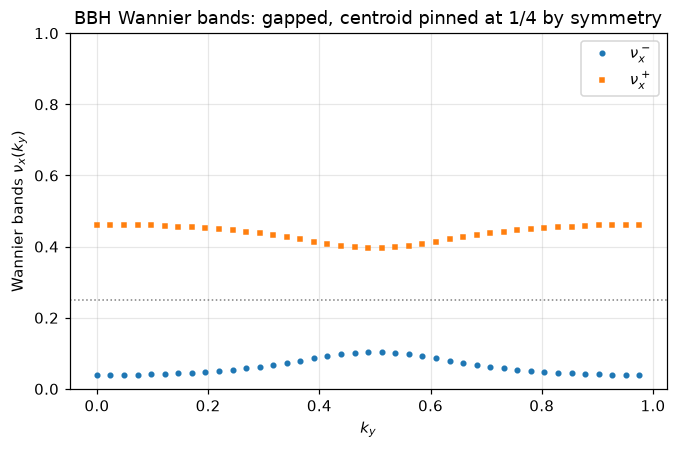

[PASS] Wannier bands remain gapped at every ky — min Wannier gap = 0.292
[PASS] Wannier-band centroid pinned at 1/4 (mod 1/2) — centroid spread: 1.94e-16


True

In [4]:
# nested Wilson loop, by hand.
# Step 1: occupied eigenvectors on an (Nx, Ny) grid (no duplicate endpoints).
Nx, Ny = 41, 41
kx = np.arange(Nx) / Nx
ky = np.arange(Ny) / Ny
KX, KY = np.meshgrid(kx, ky, indexing="ij")
k_flat = np.stack([KX.ravel(), KY.ravel()], axis=1)
evals_g, evecs_g = qm.solve_ham(k_flat, return_eigvecs=True)
u = evecs_g.reshape(Nx, Ny, 4, 4)[:, :, :2, :]         # occupied pair, (Nx,Ny,2,norb)

# convention-I boundary factor: u_n(k+G)_tau = e^{-2pi i G.tau} u_n(k)_tau
tau = qm.orb_vecs                                       # (4, 2) reduced positions
bx = np.exp(-2j * np.pi * tau[:, 0])                    # wrap along x
by = np.exp(-2j * np.pi * tau[:, 1])                    # wrap along y

def wilson_x(u, iy):
    '''Wilson loop along kx at fixed ky index: product of link overlaps.'''
    W = np.eye(2, dtype=complex)
    for ix in range(Nx):
        u1 = u[ix, iy]
        u2 = u[(ix + 1) % Nx, iy] * (bx if ix == Nx - 1 else 1.0)
        M = u1.conj() @ u2.T                            # (2,2) overlap
        # unitarize the link (SVD) — the standard discrete Wilson loop
        A, _, Bh = np.linalg.svd(M)
        W = W @ (A @ Bh)
    return W

# Wannier bands: eigenphases of W_x(ky)
nu_x = np.zeros((Ny, 2))
v_store = np.zeros((Ny, 2, 2), dtype=complex)           # Wilson eigenvectors
for iy in range(Ny):
    W = wilson_x(u, iy)
    lam_w, v = np.linalg.eig(W)
    order = np.argsort(np.angle(lam_w))
    nu_x[iy] = np.angle(lam_w)[order] / (2 * np.pi)
    v_store[iy] = v[:, order].T                         # rows = Wannier band vectors

fig, ax = plt.subplots()
ax.plot(ky, nu_x[:, 0] % 1.0, "o", ms=3, label=r"$\nu_x^-$")
ax.plot(ky, nu_x[:, 1] % 1.0, "s", ms=3, label=r"$\nu_x^+$")
ax.axhline(0.25, color="gray", ls=":", lw=1)
ax.set_xlabel(r"$k_y$"); ax.set_ylabel(r"Wannier bands $\nu_x(k_y)$")
ax.set_ylim(0, 1); ax.legend()
ax.set_title("BBH Wannier bands: gapped, centroid pinned at 1/4 by symmetry")
plt.show()
caption("First layer of the nested construction: the Wilson-loop eigenphases "
        "(Wannier bands) ν±(ky) of the occupied pair. They disperse but never touch, "
        "and mirror symmetry pins their centroid to exactly ¼. A gapped Wannier "
        "spectrum is itself a band structure one level up — with its own Berry "
        "phase, computed next.")

# the individual bands disperse; what is quantized is (a) the gap between them
# and (b) their centroid, pinned to 1/4 (mod 1/2) by the model's mirror symmetries
nu_wrap = nu_x % 1.0
circ_gap = np.minimum(np.abs(nu_wrap[:, 1] - nu_wrap[:, 0]),
                      1 - np.abs(nu_wrap[:, 1] - nu_wrap[:, 0]))
centroid = (nu_wrap.sum(axis=1) / 2) % 0.5
check("Wannier bands remain gapped at every ky", circ_gap.min() > 0.1,
      f"min Wannier gap = {circ_gap.min():.3f}")
check("Wannier-band centroid pinned at 1/4 (mod 1/2)",
      np.allclose(centroid, 0.25, atol=1e-3),
      f"centroid spread: {np.abs(centroid - 0.25).max():.2e}")

In [5]:
# Step 2: the nested loop. Build the Wannier-band basis |w_j(kx,ky)> by parallel-
# transporting the Wilson eigenvector with partial Wilson lines, then take its
# Berry phase along ky.
def nested_polarization(u, band=0):
    phases = []
    for base_ix in range(0, Nx, 8):                     # a few base points: p_y is kx-independent
        # Wannier-band states at every ky for this base kx column
        w = np.zeros((Ny, 4), dtype=complex)
        for iy in range(Ny):
            # Wilson loop starting (and ending) at base_ix; the BZ-boundary wrap
            # factor applies on the link ix = Nx-1 -> 0 wherever it occurs
            W = np.eye(2, dtype=complex)
            for step in range(Nx):
                ix = (base_ix + step) % Nx
                nxt = (ix + 1) % Nx
                u1 = u[ix, iy]
                u2 = u[nxt, iy] * (bx if ix == Nx - 1 else 1.0)
                M = u1.conj() @ u2.T
                A, _, Bh = np.linalg.svd(M)
                W = W @ (A @ Bh)
            lam_w, v = np.linalg.eig(W)
            order = np.argsort(np.angle(lam_w))
            vj = v[:, order][:, band]
            w[iy] = vj @ u[base_ix, iy]                 # embed in orbital space
        # Berry phase of w along ky (with y-wrap on the last link)
        prod = 1.0 + 0j
        for iy in range(Ny):
            w1 = w[iy]
            w2 = w[(iy + 1) % Ny] * (by if iy == Ny - 1 else 1.0)
            ov = np.vdot(w1, w2)
            prod *= ov / abs(ov)
        phases.append((-np.angle(prod) / (2 * np.pi)) % 1.0)
    return np.array(phases)

p_y = nested_polarization(u, band=0)
print("topological p_y^(nu) at several base kx:", np.round(p_y, 4))

# the same construction on the TRIVIAL model (gamma and lambda exchanged):
# the absolute value carries a geometric offset from the orbital positions
# (tau_y in {0, 1/2}), so the quantized invariant is the DIFFERENCE mod 1.
qm_triv = bbh(1.0, 0.4)
_, evecs_t = qm_triv.solve_ham(k_flat, return_eigvecs=True)
u_triv = evecs_t.reshape(Nx, Ny, 4, 4)[:, :, :2, :]
p_y_triv = nested_polarization(u_triv, band=0)
print("trivial     p_y^(nu) at several base kx:", np.round(p_y_triv, 4))

dp = (p_y.mean() - p_y_triv.mean()) % 1.0
check("nested Wilson polarizations are kx-independent (both phases)",
      p_y.std() < 1e-3 and p_y_triv.std() < 1e-3)
check("Wannier-sector polarization jumps by exactly 1/2 across the transition",
      np.isclose(dp, 0.5, atol=0.02),
      f"p_y(topo) - p_y(trivial) = {dp:.4f} mod 1")

topological p_y^(nu) at several base kx: [0.75 0.75 0.75 0.75 0.75 0.75]


trivial     p_y^(nu) at several base kx: [0.25 0.25 0.25 0.25 0.25 0.25]
[PASS] nested Wilson polarizations are kx-independent (both phases)
[PASS] Wannier-sector polarization jumps by exactly 1/2 across the transition — p_y(topo) - p_y(trivial) = 0.5000 mod 1


True

<a id="sec-18"></a>

## 18. The Kitaev chain — superconductivity smuggled in as extra orbitals

PythTB has no notion of superconductivity: no Nambu space, no particle-hole symmetry class, no
anomalous terms. Kwant doesn't either, strictly — but Kwant's arbitrary-matrix onsites make BdG
natural, and its S-matrix machinery then computes Andreev physics. Here we *smuggle* the
Bogoliubov–de Gennes Hamiltonian into PythTB by declaring particle and hole components to be two
"orbitals":
$$
H_{BdG}(k) = \bigl[-2t\cos K - \mu\bigr]\tau_z + 2\Delta \sin K\,\tau_y ,
$$
the mean-field Kitaev chain. The recipe: orbital 0 gets the electron Hamiltonian, orbital 1 gets
$-H^*$, and the pairing $\Delta(c^\dagger_i c^\dagger_{i+1} + h.c.)$ becomes an orbital-off-diagonal
"hopping" antisymmetric under $i \leftrightarrow j$. For $|\mu| < 2t$ the chain is topological and
an open chain binds one **Majorana zero mode per end**.

What PythTB does *not* do for us here is exactly what makes this a stretch: it cannot verify
particle-hole symmetry (we check it by hand), it doesn't know the spectrum is redundant (every
state appears at $\pm E$), and its Berry-phase tools compute the invariant only if *we* know which
symmetry class to interpret it in. No guardrails — compare Kwant's `conservation_law` /
`particle_hole` machinery (Part IV, §28).

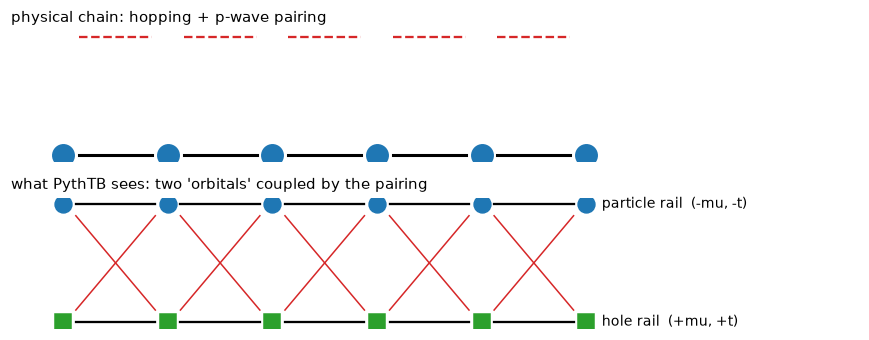

In [6]:
# the physical chain and its BdG shadow, drawn: one row of spinless sites with
# hopping t and p-wave pairing Delta on the same bonds; below it, the DOUBLED
# ladder PythTB actually diagonalizes (particle rail + hole rail)
fig, axs = plt.subplots(2, 1, figsize=(8, 3.2))
xs = np.arange(6)
axs[0].plot(xs, 0 * xs, "o", ms=14, color="C0", zorder=3)
for x in xs[:-1]:
    axs[0].plot([x + 0.15, x + 0.85], [0, 0], "-", color="k", lw=2)
    axs[0].plot([x + 0.15, x + 0.85], [0.16, 0.16], "--", color="C3", lw=1.5)
axs[0].annotate("t", (2.5, -0.22), ha="center", fontsize=12)
axs[0].annotate(r"$\Delta\, c_i c_{i+1}$", (2.5, 0.30), ha="center", fontsize=11, color="C3")
axs[0].set_title("physical chain: hopping + p-wave pairing", fontsize=10, loc="left")
axs[1].plot(xs, 0 * xs + 0.3, "o", ms=11, color="C0", zorder=3)
axs[1].plot(xs, 0 * xs - 0.3, "s", ms=11, color="C2", zorder=3)
for x in xs[:-1]:
    axs[1].plot([x + 0.12, x + 0.88], [0.3, 0.3], "-", color="k", lw=1.5)
    axs[1].plot([x + 0.12, x + 0.88], [-0.3, -0.3], "-", color="k", lw=1.5)
    axs[1].plot([x + 0.12, x + 0.88], [0.24, -0.24], "-", color="C3", lw=1)
    axs[1].plot([x + 0.12, x + 0.88], [-0.24, 0.24], "-", color="C3", lw=1)
axs[1].annotate("particle rail  (-mu, -t)", (5.15, 0.3), fontsize=9, va="center")
axs[1].annotate("hole rail  (+mu, +t)", (5.15, -0.3), fontsize=9, va="center")
axs[1].set_title("what PythTB sees: two 'orbitals' coupled by the pairing", fontsize=10, loc="left")
for ax in axs:
    ax.set_xlim(-0.5, 7.6); ax.axis("off")
fig.tight_layout()
plt.show()
caption("Top: the physical Kitaev chain — spinless fermions with hopping t and "
        "p-wave pairing Δ that creates/destroys PAIRS on neighbouring sites. "
        "Bottom: the Bogoliubov–de Gennes doubling PythTB actually diagonalizes — "
        "a particle rail and a hole rail (with negated parameters), the anomalous "
        "pairing recast as an ordinary inter-rail 'hopping' (red). The doubling is "
        "exact but redundant: every physical excitation appears twice, at ±E.")

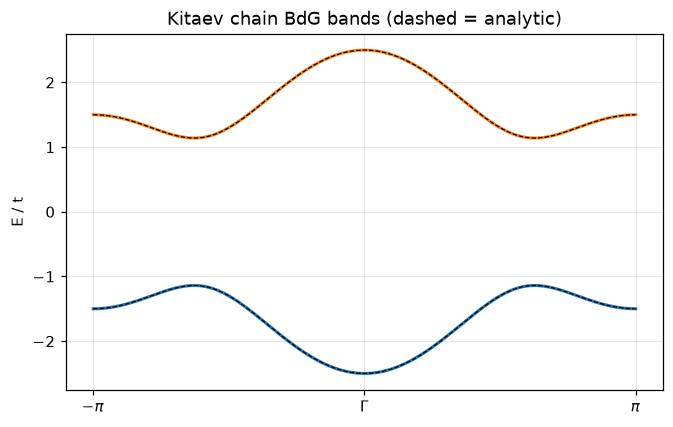

[PASS] BdG spectrum matches analytic Kitaev dispersion
[PASS] particle-hole symmetry E(k) = -E(-k) holds


True

In [7]:
def kitaev(mu, t=1.0, Delta=0.6):
    '''BdG Kitaev chain: orbital 0 = particle, orbital 1 = hole (both at tau=0).'''
    lat = Lattice(lat_vecs=[[1.0]], orb_vecs=[[0.0], [0.0]], periodic_dirs=[0])
    m = TBModel(lat)
    m.set_onsite([-mu, +mu])
    m.set_hop(-t, 0, 0, [1])                 # electron hops
    m.set_hop(+t, 1, 1, [1])                 # hole partner: -(-t)* = +t
    # pairing 2*Delta*sin(K) tau_y:  H_01(k) = -2i*Delta*sin(K)
    m.set_hop(-Delta, 0, 1, [1])
    m.set_hop(+Delta, 0, 1, [-1], allow_conjugate_pair=True)
    return m

# bulk check against the analytic BdG dispersion
mu = 0.5
kit = kitaev(mu)
k_vec, k_dist, k_node = kit.k_path([[-0.5], [0.0], [0.5]], nk=201, report=False)
ev = kit.solve_ham(k_vec)
K = 2 * np.pi * k_vec[:, 0]
E_bdg = np.sqrt((2 * 1.0 * np.cos(K) + mu) ** 2 + (2 * 0.6 * np.sin(K)) ** 2)

fig, ax = plt.subplots()
ax.plot(k_dist, ev, lw=2)
ax.plot(k_dist, E_bdg, "k--", lw=0.8); ax.plot(k_dist, -E_bdg, "k--", lw=0.8)
ax.set_xticks(k_node, [r"$-\pi$", r"$\Gamma$", r"$\pi$"])
ax.set_ylabel("E / t"); ax.set_title("Kitaev chain BdG bands (dashed = analytic)")
plt.show()
caption("BdG bands of the Kitaev chain (solid) on top of the analytic dispersion "
        "±√(ξ² + Δ²ₖ) (dashed). The pairing gaps the would-be Fermi points of the "
        "normal chain; the gap at k = ±π/2 is purely superconducting (∝ Δ), while "
        "the gap at k = 0 and π is set by |μ ∓ 2t| — and it is the latter that "
        "closes and reopens at the topological transition μ = 2t.")

check("BdG spectrum matches analytic Kitaev dispersion",
      np.allclose(np.sort(ev, axis=1), np.sort(np.stack([-E_bdg, E_bdg], 1), axis=1),
                  atol=1e-10))
# particle-hole symmetry check — BY HAND, because PythTB cannot do it for us
check("particle-hole symmetry E(k) = -E(-k) holds",
      np.allclose(np.sort(ev, axis=1), -np.sort(ev[::-1], axis=1)[:, ::-1], atol=1e-10))

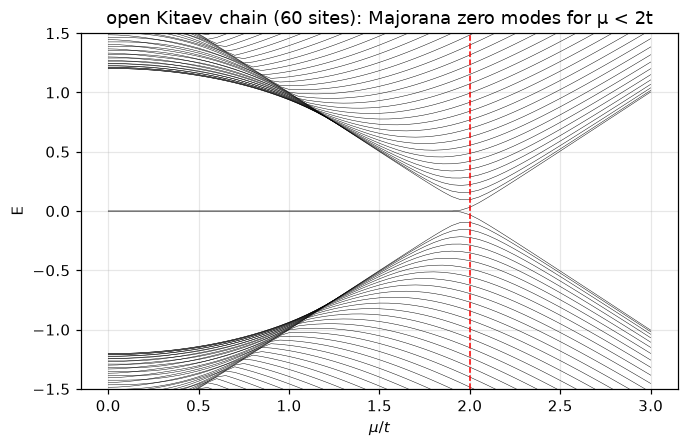

[PASS] zero mode in the topological phase, none in the trivial phase — E0(mu=0.5) = 1.1e-15, E0(mu=2.8) = 0.805


True

In [8]:
# open chain: Majorana end modes appear exactly in |mu| < 2t
N = 60
mu_scan = np.linspace(0.0, 3.0, 61)
spec = np.array([kitaev(m_).cut_piece(N, 0).solve_ham() for m_ in mu_scan])

fig, ax = plt.subplots()
ax.plot(mu_scan, spec, "k-", lw=0.3)
ax.axvline(2.0, color="r", ls="--", lw=1)
ax.set_xlabel(r"$\mu / t$"); ax.set_ylabel("E")
ax.set_ylim(-1.5, 1.5)
ax.set_title(f"open Kitaev chain ({N} sites): Majorana zero modes for μ < 2t")
plt.show()
caption("Open-chain BdG spectrum versus chemical potential: throughout the "
        "topological phase |μ| < 2t a pair of states clings to E = 0, splitting "
        "only exponentially in system size; past the bulk transition they merge "
        "into the continuum. This zero-bias pinning is exactly the feature hunted "
        "in tunneling experiments on proximitized nanowires — with the caveat that "
        "a tunneling CONDUCTANCE calculation is Kwant's territory, not PythTB's.")

E0_topo = np.abs(spec[np.argmin(np.abs(mu_scan - 0.5))]).min()
E0_triv = np.abs(spec[np.argmin(np.abs(mu_scan - 2.8))]).min()
check("zero mode in the topological phase, none in the trivial phase",
      E0_topo < 1e-8 and E0_triv > 0.05,
      f"E0(mu=0.5) = {E0_topo:.1e}, E0(mu=2.8) = {E0_triv:.3f}")

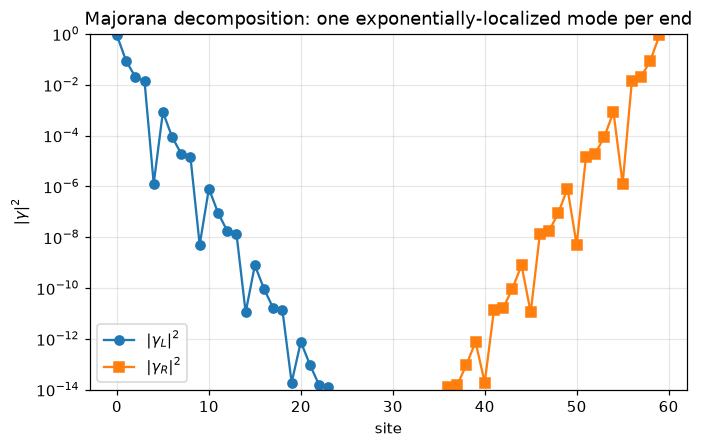

[PASS] Majorana combinations localize on opposite ends
[PASS] Majorana has equal particle and hole weight — u-weight 0.500000 vs v-weight 0.500000


True

In [9]:
# the Majorana structure: the two E~0 eigenstates combine into Majoranas
# gamma_L/R = (psi_0 ± psi_1)/sqrt(2), each localized at ONE end with |u| = |v|
fin = kitaev(0.5).cut_piece(N, 0)
evals, evecs = fin.solve_ham(return_eigvecs=True)
i2 = np.argsort(np.abs(evals))[:2]
psi_p, psi_m = evecs[i2[0]], evecs[i2[1]]

# numpy returns the +-E pair with arbitrary phases, so "psi_p ± psi_m" is not
# gauge-safe. Instead diagonalize the left-half weight inside the 2D zero-energy
# subspace: its eigenvectors are the maximally end-localized combinations.
half_L = fin.orb_vecs[:, 0] < N / 2
V = np.stack([psi_p, psi_m], axis=0)                  # (2, n_orb) subspace basis
O_L = (V * half_L) @ V.conj().T                       # 2x2 left-weight operator
wts, cvec = np.linalg.eigh(O_L)
gam_2 = cvec[:, 0] @ V                                # least left weight  -> right end
gam_1 = cvec[:, 1] @ V                                # most  left weight -> left end

x_site = fin.orb_vecs[::2, 0]                     # one position per site
d1 = (np.abs(gam_1) ** 2).reshape(N, 2).sum(1)
d2 = (np.abs(gam_2) ** 2).reshape(N, 2).sum(1)

fig, ax = plt.subplots()
ax.semilogy(x_site, d1, "o-", label=r"$|\gamma_L|^2$")
ax.semilogy(x_site, d2, "s-", label=r"$|\gamma_R|^2$")
ax.set_xlabel("site"); ax.set_ylabel(r"$|\gamma|^2$")
ax.set_ylim(1e-14, 1)
ax.legend(); ax.set_title("Majorana decomposition: one exponentially-localized mode per end")
plt.show()
caption("The two E ≈ 0 BdG eigenstates recombined into maximally end-localized "
        "combinations: each is a MAJORANA mode — equal particle and hole content, "
        "exponentially confined to one end. A single fermionic level (occupied or "
        "empty) is physically split across the two chain ends; no local probe can "
        "measure its occupation, which is the storage principle of topological "
        "qubits.")

check("Majorana combinations localize on opposite ends",
      d1[:N//2].sum() > 0.99 * d1.sum() and d2[N//2:].sum() > 0.99 * d2.sum())

# electron-hole weight balance: a Majorana has |u| = |v| exactly
uu = np.abs(gam_1.reshape(N, 2)[:, 0]) ** 2
vv = np.abs(gam_1.reshape(N, 2)[:, 1]) ** 2
check("Majorana has equal particle and hole weight", np.isclose(uu.sum(), vv.sum(), atol=1e-3),
      f"u-weight {uu.sum():.6f} vs v-weight {vv.sum():.6f}")

In [10]:
# ---- tally for this notebook ---------------------------------------------------
print("=" * 66)
print(f"chapter 5 — checks passed : {_CHECKS['pass']}")
print(f"chapter 5 — checks failed : {_CHECKS['fail']}")
print(f"wall time                 : {time.time() - t_chapter_start:.0f} s")
print("=" * 66)
print("Every quantitative claim in this notebook was verified in this run."
      if _CHECKS["fail"] == 0 else "Some checks FAILED — search this notebook for '[FAIL]'.")

chapter 5 — checks passed : 12
chapter 5 — checks failed : 0
wall time                 : 9 s
Every quantitative claim in this notebook was verified in this run.
